### Train--Regularization

#### 一、Weight Decay
权重衰退本质上就是 L2 正则化  
- 直观理解：如果神经网络的权重 W 变得非常大，模型就会变得极度敏感。输入稍微变一点点，输出就翻江倒海。这就像一个过于神经质的人，一点风吹草动就大喊大叫  
- 解决方案：在损失函数中加入权重衰退项，使权重 W 逐渐变小，从而避免权重过大
- 效果：模型精度提高，但权重变小，模型参数变小，模型变简单

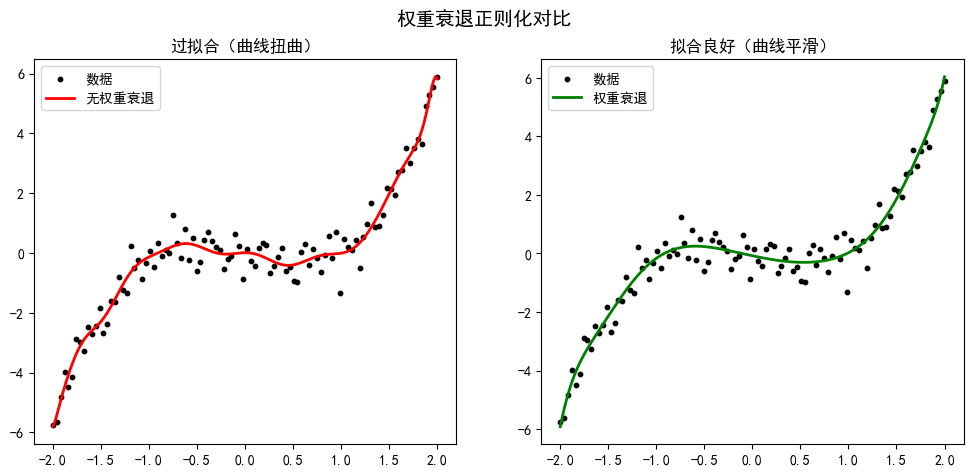

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
import matplotlib
matplotlib.rcParams['font.sans-serif'] = ['SimHei']     # 显示中文
matplotlib.rcParams['axes.unicode_minus'] = False
np.random.seed(42)
x = np.linspace(-2, 2, 100)
y_true = x ** 3 - x + np.random.normal(0, 0.5, size=x.shape)
x = x.reshape(-1, 1)

# 多项式特征（高维，极易过拟合）
def poly_model(alpha=0):
    return Pipeline([
        ("poly", PolynomialFeatures(degree=20)),  # 高次多项式
        ("scaler", StandardScaler()),
        # Ridge = 线性回归 + L2正则化（权重衰退）
        ("model", Ridge(alpha=alpha))  # alpha=λ
    ])

# 训练两个模型：无正则化 vs 权重衰退
model_no_reg = poly_model(alpha=0)  # 无权重衰退
model_weight_decay = poly_model(alpha=1e-2)  # 权重衰退

model_no_reg.fit(x, y_true)
model_weight_decay.fit(x, y_true)

# 预测
x_plot = np.linspace(-2, 2, 200).reshape(-1, 1)
y_pred_no_reg = model_no_reg.predict(x_plot)
y_pred_weight_decay = model_weight_decay.predict(x_plot)

# 可视化
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(x, y_true, s=10, color='k', label='数据')
plt.plot(x_plot, y_pred_no_reg, color='r', linewidth=2, label='无权重衰退')
plt.title("过拟合（曲线扭曲）")
plt.legend()

plt.subplot(1, 2, 2)
plt.scatter(x, y_true, s=10, color='k', label='数据')
plt.plot(x_plot, y_pred_weight_decay, color='g', linewidth=2, label='权重衰退')
plt.title("拟合良好（曲线平滑）")
plt.legend()

plt.suptitle("权重衰退正则化对比", fontsize=14)
plt.show()

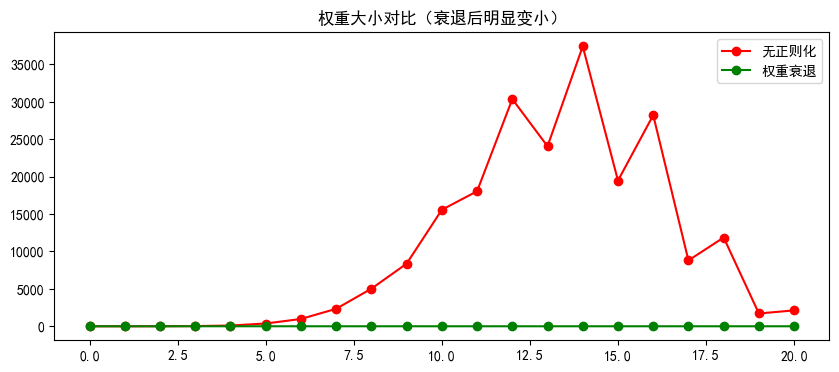

In [3]:
# 查看权重大小
w_no_reg = model_no_reg.named_steps["model"].coef_
w_weight_decay = model_weight_decay.named_steps["model"].coef_

plt.figure(figsize=(10,4))
plt.plot(np.abs(w_no_reg), 'r-o', label='无正则化')
plt.plot(np.abs(w_weight_decay), 'g-o', label='权重衰退')
plt.title("权重大小对比（衰退后明显变小）")
plt.legend()
plt.show()

#### 二、Droupout
在训练的每一轮中，我们随机让一部分神经元“休假”（输出设为 0）
- 如果所有神经元都在线，它们会产生“依赖心理”，几个神经元聚在一起只记某个特定的噪声。如果随机把一些神经元踢走，剩下的神经元就必须学会“自立自强”，不依赖特定的伙伴也能识别出“猫”或者“狗”
- 它强迫模型学习更鲁棒（Robust）的特征，极大地提升了模型的泛化能力


==== 训练 无 Dropout ====
Epoch 0, Loss: 96.9494
Epoch 100, Loss: 11.2080
Epoch 200, Loss: 5.8583
Epoch 300, Loss: 3.3233
Epoch 400, Loss: 2.5099
Epoch 500, Loss: 2.2671
Epoch 600, Loss: 2.1777
Epoch 700, Loss: 2.1296

==== 训练 带 Dropout ====
Epoch 0, Loss: 97.3381
Epoch 100, Loss: 13.5166
Epoch 200, Loss: 9.0371
Epoch 300, Loss: 6.2147
Epoch 400, Loss: 4.5443
Epoch 500, Loss: 4.3829
Epoch 600, Loss: 4.2495
Epoch 700, Loss: 4.5332


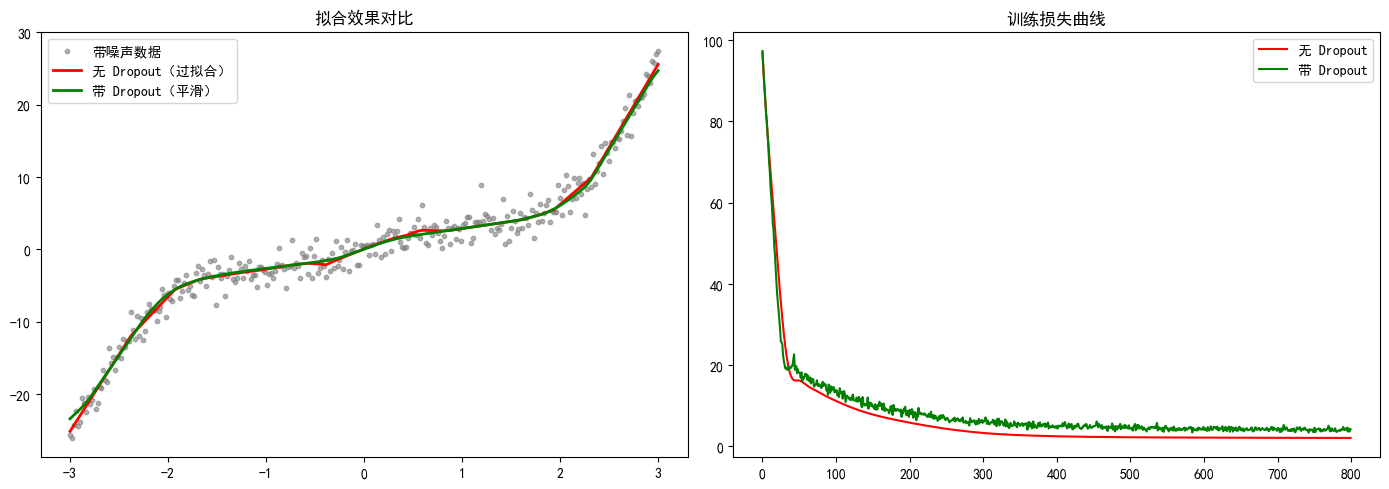

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib
matplotlib.rcParams['font.sans-serif'] = ['SimHei']     # 显示中文
matplotlib.rcParams['axes.unicode_minus'] = False

np.random.seed(42)
x = np.linspace(-3, 3, 300)
y = x**3 + 2*np.sin(x*2) + np.random.normal(0, 1.5, size=x.shape)  # 带噪声

# 转张量
x_tensor = torch.tensor(x, dtype=torch.float32).reshape(-1, 1)
y_tensor = torch.tensor(y, dtype=torch.float32).reshape(-1, 1)


# 构建网络：带 Dropout vs 不带 Dropout

class Net(nn.Module):
    def __init__(self, use_dropout=False, p=0.3):
        super().__init__()
        self.use_dropout = use_dropout
        self.fc1 = nn.Linear(1, 128)
        self.fc2 = nn.Linear(128, 128)
        self.fc3 = nn.Linear(128, 1)
        self.dropout = nn.Dropout(p)  # Dropout层
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.relu(self.fc1(x))
        if self.use_dropout:
            x = self.dropout(x)  # 第一层后丢
        x = self.relu(self.fc2(x))
        if self.use_dropout:
            x = self.dropout(x)  # 第二层后丢
        x = self.fc3(x)
        return x


# 训练函数
def train(model, epochs=800, lr=0.001):
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    losses = []
    model.train()
    
    for epoch in range(epochs):
        y_pred = model(x_tensor)
        loss = criterion(y_pred, y_tensor)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        losses.append(loss.item())
        
        if epoch % 100 == 0:
            print(f"Epoch {epoch}, Loss: {loss.item():.4f}")
    return losses


# 训练两个模型

model_no_drop = Net(use_dropout=False)
model_with_drop = Net(use_dropout=True, p=0.3)

print("\n==== 训练 无 Dropout ====")
loss_no_drop = train(model_no_drop)

print("\n==== 训练 带 Dropout ====")
loss_with_drop = train(model_with_drop)


model_no_drop.eval()
model_with_drop.eval()
with torch.no_grad():
    y_pred_no_drop = model_no_drop(x_tensor).numpy()
    y_pred_with_drop = model_with_drop(x_tensor).numpy()

plt.figure(figsize=(14, 5))

# 拟合效果对比
plt.subplot(1, 2, 1)
plt.scatter(x, y, s=10, c='gray', alpha=0.6, label='带噪声数据')
plt.plot(x, y_pred_no_drop, 'r-', linewidth=2, label='无 Dropout（过拟合）')
plt.plot(x, y_pred_with_drop, 'g-', linewidth=2, label='带 Dropout（平滑）')
plt.title('拟合效果对比')
plt.legend()

# 损失曲线对比
plt.subplot(1, 2, 2)
plt.plot(loss_no_drop, 'r', label='无 Dropout')
plt.plot(loss_with_drop, 'g', label='带 Dropout')
plt.title('训练损失曲线')
plt.legend()

plt.tight_layout()
plt.show()

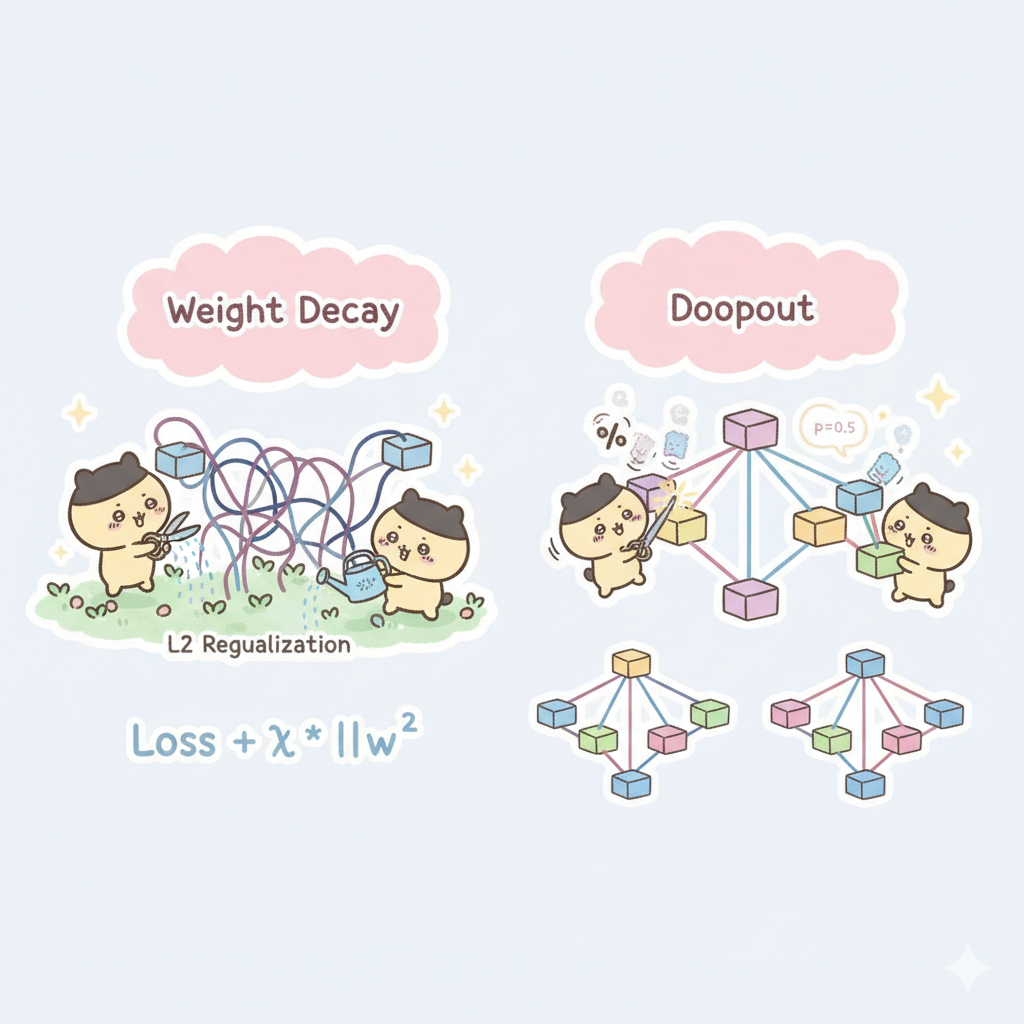